In [75]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix,ConfusionMatrixDisplay

In [77]:
df = pd.read_csv("spotify_data clean.csv")

In [79]:
df

,track_id,track_name,track_number,track_popularity,explicit,artist_name,artist_popularity,artist_followers,artist_genres,album_id,album_name,album_release_date,album_total_tracks,album_type,track_duration_min
0,3EJS5LyekDim1Tf5rBFmZl,Trippy Mane (ft. Project Pat),4,0,True,Diplo,77,2812821,moombahton,5QRFnGnBeMGePBKF2xTz5z,"d00mscrvll, Vol. 1",2025-10-31,9,album,1.55
1,1oQW6G2ZiwMuHqlPpP27DB,OMG!,1,0,True,Yelawolf,64,2363438,"country hip hop, southern hip hop",4SUmmwnv0xTjRcLdjczGg2,OMG!,2025-10-31,1,single,3.07
2,7mdkjzoIYlf1rx9EtBpGmU,Hard 2 Find,1,4,True,Riff Raff,48,193302,NaN,3E3zEAL8gUYWaLYB9L7gbp,Hard 2 Find,2025-10-31,1,single,2.55
3,67rW0Zl7oB3qEpD5YWWE5w,Still Get Like That (ft. Project Pat & Starrah),8,30,True,Diplo,77,2813710,moombahton,5QRFnGnBeMGePBKF2xTz5z,"d00mscrvll, Vol. 1",2025-10-31,9,album,1.69
4,15xptTfRBrjsppW0INUZjf,ride me like a harley,2,0,True,Rumelis,48,8682,dark r&b,06FDIpSHYmZAZoyuYtc7kd,come closer / ride me like a harley,2025-10-30,2,single,2.39
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8577,0AQquaENerGps8BQmbPw14,Big Iron,1,71,False,Marty Robbins,60,626733,"classic country, outlaw country",3kQpBS26lAj0A0VGl1snRl,Gunfighter Ballads And Trail Songs,1959-06-30,15,album,3.92
8578,4f8hBeMXMvssn6HtFAtblo,El Paso,10,64,False,Marty Robbins,61,626733,"classic country, outlaw country",3kQpBS26lAj0A0VGl1snRl,Gunfighter Ballads And Trail Songs,1959-06-30,15,album,4.32
8579,0Vy7wsXNFrbNc6UTWoScnM,Over the Rainbow,5,8,False,The Mystics,27,18184,doo-wop,2ifB9Xjp9DdpqLlYlY60QW,Presenting The Mystics,1959-02-11,9,compilation,2.28
8580,760clbeDBWmBsBLbszWuNZ,I'm A Man,2,55,False,Bo Diddley,44,333376,"blues, classic blues, rock and roll, rockabilly",1cbtDEwxCjMhglb49OgNBR,Bo Diddley,1958-01-01,12,album,2.74


In [81]:
df.isnull().sum()

track_id                 0
track_name               0
track_number             0
track_popularity         0
explicit                 0
artist_name              3
artist_popularity        0
artist_followers         0
artist_genres         3361
album_id                 0
album_name               0
album_release_date       0
album_total_tracks       0
album_type               0
track_duration_min       0
dtype: int64

In [83]:
df=df.dropna()

In [85]:
df.isnull().sum()

track_id              0
track_name            0
track_number          0
track_popularity      0
explicit              0
artist_name           0
artist_popularity     0
artist_followers      0
artist_genres         0
album_id              0
album_name            0
album_release_date    0
album_total_tracks    0
album_type            0
track_duration_min    0
dtype: int64

In [87]:
df.head()

,track_id,track_name,track_number,track_popularity,explicit,artist_name,artist_popularity,artist_followers,artist_genres,album_id,album_name,album_release_date,album_total_tracks,album_type,track_duration_min
0,3EJS5LyekDim1Tf5rBFmZl,Trippy Mane (ft. Project Pat),4,0,True,Diplo,77,2812821,moombahton,5QRFnGnBeMGePBKF2xTz5z,"d00mscrvll, Vol. 1",2025-10-31,9,album,1.55
1,1oQW6G2ZiwMuHqlPpP27DB,OMG!,1,0,True,Yelawolf,64,2363438,"country hip hop, southern hip hop",4SUmmwnv0xTjRcLdjczGg2,OMG!,2025-10-31,1,single,3.07
3,67rW0Zl7oB3qEpD5YWWE5w,Still Get Like That (ft. Project Pat & Starrah),8,30,True,Diplo,77,2813710,moombahton,5QRFnGnBeMGePBKF2xTz5z,"d00mscrvll, Vol. 1",2025-10-31,9,album,1.69
4,15xptTfRBrjsppW0INUZjf,ride me like a harley,2,0,True,Rumelis,48,8682,dark r&b,06FDIpSHYmZAZoyuYtc7kd,come closer / ride me like a harley,2025-10-30,2,single,2.39
5,4ccpCcZYseq8VrPMK1EDs0,BLEED,1,2,False,Minzie,46,7218,dark r&b,2NQv9p3ZQW0Ed1LB9enix8,BLEED,2025-10-30,3,single,2.76


In [89]:
df.tail()

,track_id,track_name,track_number,track_popularity,explicit,artist_name,artist_popularity,artist_followers,artist_genres,album_id,album_name,album_release_date,album_total_tracks,album_type,track_duration_min
8577,0AQquaENerGps8BQmbPw14,Big Iron,1,71,False,Marty Robbins,60,626733,"classic country, outlaw country",3kQpBS26lAj0A0VGl1snRl,Gunfighter Ballads And Trail Songs,1959-06-30,15,album,3.92
8578,4f8hBeMXMvssn6HtFAtblo,El Paso,10,64,False,Marty Robbins,61,626733,"classic country, outlaw country",3kQpBS26lAj0A0VGl1snRl,Gunfighter Ballads And Trail Songs,1959-06-30,15,album,4.32
8579,0Vy7wsXNFrbNc6UTWoScnM,Over the Rainbow,5,8,False,The Mystics,27,18184,doo-wop,2ifB9Xjp9DdpqLlYlY60QW,Presenting The Mystics,1959-02-11,9,compilation,2.28
8580,760clbeDBWmBsBLbszWuNZ,I'm A Man,2,55,False,Bo Diddley,44,333376,"blues, classic blues, rock and roll, rockabilly",1cbtDEwxCjMhglb49OgNBR,Bo Diddley,1958-01-01,12,album,2.74
8581,61GEP8lryEfcuEgBMbRmNi,Alone And Forsaken,11,45,False,Hank Williams,55,1067339,"classic country, honky tonk, traditional count...",3cusZESjkIDnDXyQwbpSsT,Moanin' The Blues (Expanded Edition),1952-09-12,12,album,2.02


In [91]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5221 entries, 0 to 8581
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   track_id            5221 non-null   object 
 1   track_name          5221 non-null   object 
 2   track_number        5221 non-null   int64  
 3   track_popularity    5221 non-null   int64  
 4   explicit            5221 non-null   bool   
 5   artist_name         5221 non-null   object 
 6   artist_popularity   5221 non-null   int64  
 7   artist_followers    5221 non-null   int64  
 8   artist_genres       5221 non-null   object 
 9   album_id            5221 non-null   object 
 10  album_name          5221 non-null   object 
 11  album_release_date  5221 non-null   object 
 12  album_total_tracks  5221 non-null   int64  
 13  album_type          5221 non-null   object 
 14  track_duration_min  5221 non-null   float64
dtypes: bool(1), float64(1), int64(5), object(8)
memory usage: 61

In [93]:
df.describe()

,track_number,track_popularity,artist_popularity,artist_followers,album_total_tracks,track_duration_min
count,5221.000000,5221.000000,5221.000000,5.221000e+03,5221.000000,5221.000000
mean,6.465237,53.555258,74.588776,3.383704e+07,15.893124,3.564999
std,6.324842,22.987208,17.178821,4.472907e+07,13.101610,1.133062
min,1.000000,0.000000,2.000000,4.000000e+00,1.000000,0.140000
25%,1.000000,41.000000,63.000000,1.303279e+06,10.000000,2.900000
50%,5.000000,59.000000,79.000000,1.096042e+07,14.000000,3.510000
75%,10.000000,71.000000,88.000000,4.771699e+07,19.000000,4.080000
max,102.000000,99.000000,100.000000,1.455421e+08,181.000000,13.510000


In [95]:
df.ndim

2

In [97]:
df.shape

(5221, 15)

In [ ]:

import seaborn as sns
sns.scatterplot(x=df["artist_popularity"],y=df["track_popularity"])
plt.title("Artist Popularity vs Track Popularity")
plt.show()

In [99]:
X = df[['track_popularity','artist_popularity','track_duration_min']]
y = df['explicit']

In [101]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [103]:
lr = LogisticRegression()
lr.fit(X_train, y_train)


LogisticRegression()

In [105]:
lr_pred = lr.predict(X_test)

In [107]:
lr_pred

array([False, False, False, ..., False, False, False])

In [109]:
dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)


DecisionTreeClassifier()

In [111]:
dt_pred = dt.predict(X_test)

In [113]:
dt_pred

array([ True, False, False, ...,  True, False, False])

In [115]:
lr_acc = accuracy_score(y_test, lr_pred)
dt_acc = accuracy_score(y_test, dt_pred)

In [117]:
lr_acc

0.7559808612440191

In [119]:
dt_acc

0.7330143540669857

In [121]:
print("Logistic Regression Report")
print(classification_report(y_test, lr_pred))

print("Decision Tree Report")
print(classification_report(y_test, dt_pred))

Logistic Regression Report
              precision    recall  f1-score   support

       False       0.76      1.00      0.86       788
        True       0.75      0.01      0.02       257

    accuracy                           0.76      1045
   macro avg       0.75      0.51      0.44      1045
weighted avg       0.75      0.76      0.65      1045

Decision Tree Report
              precision    recall  f1-score   support

       False       0.83      0.82      0.82       788
        True       0.46      0.47      0.46       257

    accuracy                           0.73      1045
   macro avg       0.64      0.64      0.64      1045
weighted avg       0.74      0.73      0.73      1045



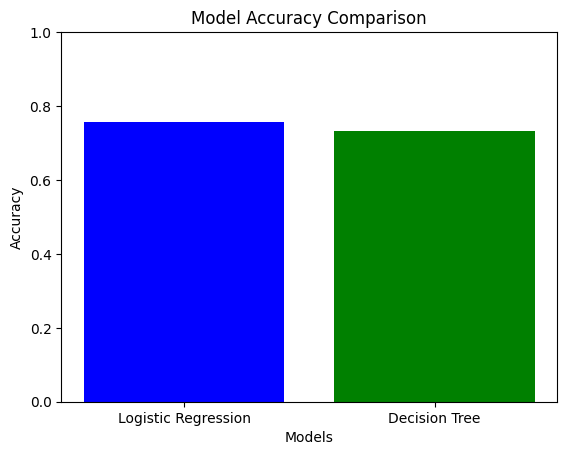

In [123]:
models = ['Logistic Regression', 'Decision Tree']
accuracy = [lr_acc, dt_acc]

colors = ['blue', 'green']

plt.bar(models, accuracy, color=colors)
plt.title("Model Accuracy Comparison")
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.ylim(0,1)

plt.show()

In [125]:
cm = confusion_matrix(y_test, lr_pred)

In [139]:
cm

array([[645, 143],
       [136, 121]])

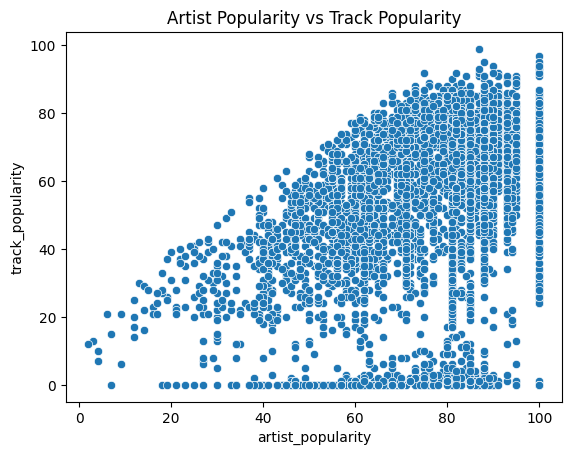